# Experiment 06 — Synthesis 3.1: The Theoretical Peak (Stable Edition)

**Goal:** Achieve the absolute highest AUC by combining architectural 'wins' with Identity-Block initialization and QNG optimization.

### Synthesis 3.1 Configuration:
| Component | Choice | Reason |
|---|---|---|
| **Samples** | 1,000 (600 Train) | Proven Small-Data Advantage |
| **Features** | 8 (Top Correlation) | Maximum information density |
| **Encoding** | Data Re-uploading | Maximizes non-linearity per qubit |
| **Layers** | 3 | Peak expressivity for 8 qubits |
| **Initialization** | **Identity-Block** | Prevents early-stage vanishing gradients |
| **Optimizer** | **QNG (Mini-Batch)** | Balanced stability and Hilbert-space descent |

In [12]:
import sys
sys.path.append('..')
import time
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

# Hyperparameters
N_FEATURES = 8
N_LAYERS = 3
N_SAMPLES = 1000
N_EPOCHS = 50
BATCH_SIZE = 32
LR = 0.02

X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    path='../data/HIGGS.csv.gz', 
    n_samples=N_SAMPLES, 
    n_features=N_FEATURES, 
    scale_range=(0, np.pi), 
    random_state=42
)

Selected features (cols [26, 4, 28, 1, 6, 13, 27, 25]): ['m_bb', 'missing energy mag.', 'm_wwbb', 'lepton pT', 'jet 1 pt', 'jet 2 b-tag', 'm_wbb', 'm_jlv']
Dataset: 1000 samples | 8 features | train=600, val=200, test=200


## 1. Barren Plateau Mitigation Tools

In [13]:
def init_identity_block(n_layers, n_features, sigma=0.01, seed=42):
    """Initializes pairs of layers to start near identity (Grant et al. 2019)."""
    rng = np.random.default_rng(seed)
    weights_np = np.zeros((n_layers, n_features, 3))
    for l in range(0, n_layers - 1, 2):
        base = rng.normal(0, sigma, (n_features, 3))
        weights_np[l]     =  base
        weights_np[l + 1] = -base
    if n_layers % 2 == 1:
        weights_np[-1] = rng.normal(0, sigma, (n_features, 3))
    return pnp.array(weights_np, requires_grad=True)

dev = qml.device('lightning.qubit', wires=N_FEATURES + 1)

@qml.qnode(dev, interface='autograd')
def circuit(weights, x):
    for l in range(N_LAYERS):
        # Data Re-uploading
        for i in range(N_FEATURES):
            qml.RY(x[i], wires=i)
        # Variational rotations
        for q in range(N_FEATURES):
            qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
        # Circular Entanglement
        for q in range(N_FEATURES):
            qml.CNOT(wires=[q, (q + 1) % N_FEATURES])
    return qml.expval(qml.PauliZ(0))

## 2. Training Engine (QNG Optimized)

In [14]:
def train_vqc_stable():
    # 1. Initialize near identity
    weights = init_identity_block(N_LAYERS, N_FEATURES, sigma=0.01)
    bias = pnp.array(0.0, requires_grad=True)
    
    opt_w = qml.QNGOptimizer(stepsize=LR)
    opt_b = qml.AdamOptimizer(stepsize=LR)
    mt_fn = qml.metric_tensor(circuit, approx='block-diag')
    
    val_history = []
    t0 = time.time()
    
    print("Starting Stable Synthesis Training...")
    for epoch in range(N_EPOCHS):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]
        
        for start in range(0, len(Xs), BATCH_SIZE):
            Xb = Xs[start : start + BATCH_SIZE]
            yb = ys[start : start + BATCH_SIZE].astype(float)
            y_float = pnp.where(yb == 1, 1.0, -1.0)
            
            # Compute metric tensor using a single sample from batch
            mt = mt_fn(weights, Xb[0])
            
            def cost_w(w_):
                preds = pnp.array([circuit(w_, x) for x in Xb])
                return pnp.mean((y_float - (preds + bias)) ** 2)
            
            weights = opt_w.step(cost_w, weights, metric_tensor_fn=lambda _: mt)
            
            def cost_b(b_):
                preds = pnp.array([circuit(weights, x) for x in Xb])
                return pnp.mean((y_float - (preds + b_)) ** 2)
            
            bias = opt_b.step(cost_b, bias)
            
        # End of Epoch validation
        v_preds = np.array([float(circuit(weights, x) + bias) for x in X_val])
        v_loss = np.mean((y_val.astype(float) - v_preds)**2)
        val_history.append(v_loss)
        
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | Val MSE: {v_loss:.4f} | Time: {time.time()-t0:.1f}s")
            
    return weights, bias, val_history

w_best, b_best, history = train_vqc_stable()

Starting Stable Synthesis Training...
Epoch  1/50 | Val MSE: 1.0404 | Time: 5.9s
Epoch  5/50 | Val MSE: 1.0188 | Time: 29.9s
Epoch 10/50 | Val MSE: 1.0179 | Time: 60.3s
Epoch 15/50 | Val MSE: 1.0082 | Time: 89.7s
Epoch 20/50 | Val MSE: 1.0231 | Time: 118.3s
Epoch 25/50 | Val MSE: 1.0075 | Time: 147.2s
Epoch 30/50 | Val MSE: 0.9955 | Time: 176.0s
Epoch 35/50 | Val MSE: 0.9858 | Time: 205.1s
Epoch 40/50 | Val MSE: 0.9876 | Time: 234.6s
Epoch 45/50 | Val MSE: 0.9640 | Time: 264.0s
Epoch 50/50 | Val MSE: 0.9664 | Time: 293.2s


## 3. Final Performance Analysis


--- SYNTHESIS 3.1 RESULTS ---
Test Accuracy: 0.5850
Test AUC:      0.6218


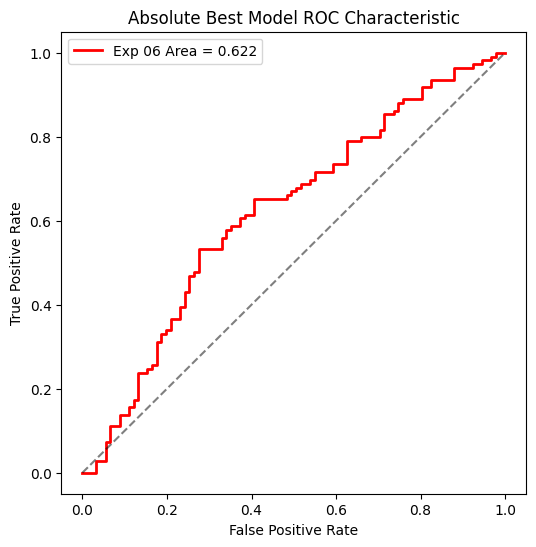

In [15]:
test_raw = np.array([float(circuit(w_best, x) + b_best) for x in X_test])
test_auc = roc_auc_score((y_test == 1).astype(int), test_raw)
test_acc = binary_accuracy(y_test, test_raw)

print(f"\n--- SYNTHESIS 3.1 RESULTS ---")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC:      {test_auc:.4f}")

fpr, tpr, _ = roc_curve((y_test == 1).astype(int), test_raw)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Exp 06 Area = {test_auc:.3f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Absolute Best Model ROC Characteristic')
plt.legend()
plt.show()